#Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

RANDOM_STATE = 42

#Load the Data

In [2]:
import os

DATA_FILE = "retail_transactions_segmentation.csv"

if not os.path.exists(DATA_FILE):
    from google.colab import files
    uploaded = files.upload()
    uploaded_name = list(uploaded.keys())[0]
    if uploaded_name != DATA_FILE:
        os.rename(uploaded_name, DATA_FILE)

print("Ready to load:", os.path.exists(DATA_FILE))

Saving retail_transactions_segmentation.csv.xls to retail_transactions_segmentation.csv.xls
Ready to load: True


In [3]:
df = pd.read_csv(DATA_FILE)
df.head(10)

,customer_id,transaction_date,amount,product_category
0,5206,2024-01-31,162.65,Fashion
1,5153,2024-07-03,389.85,Fashion
2,5102,2024-11-13,453.72,Home & Living
3,5073,2024-03-11,824.74,Electronics
4,5097,2024-12-28,181.74,Sports
5,5059,2024-06-11,885.21,Sports
6,5288,2024-11-17,318.49,Groceries
7,5073,2024-12-07,717.91,Sports
8,5073,2024-11-16,1506.36,Home & Living
9,5274,2024-09-13,235.12,Home & Living


#Inspect the Data

In [4]:
print("Shape:", df.shape)
print("\nDtypes:")
print(df.dtypes)

Shape: (3663, 4)

Dtypes:
customer_id           int64
transaction_date     object
amount              float64
product_category     object
dtype: object


In [5]:
print("Missing values per column:")
print(df.isnull().sum())

print("\nFully duplicated rows:", df.duplicated().sum())

print("\nUnique customers:", df['customer_id'].nunique())
print("Product categories:", df['product_category'].unique())

Missing values per column:
customer_id         0
transaction_date    0
amount              0
product_category    0
dtype: int64

Fully duplicated rows: 0

Unique customers: 300
Product categories: ['Fashion' 'Home & Living' 'Electronics' 'Sports' 'Groceries' 'Beauty']


In [6]:
df['amount'].describe()

,amount
count,3663.000000
mean,513.028376
std,305.332100
min,5.000000
25%,276.550000
50%,411.870000
75%,767.740000
max,1506.360000


In [7]:
# Check for bad rows and confirm the date range
print("Transactions with amount <= 0:", (df['amount'] <= 0).sum())

df['transaction_date'] = pd.to_datetime(df['transaction_date'])
print("Date range:", df['transaction_date'].min(), "to", df['transaction_date'].max())

Transactions with amount <= 0: 0
Date range: 2024-01-01 00:00:00 to 2024-12-30 00:00:00


# Clean & Preprocess

In [8]:
# Check for whitespace-only or hidden-padding issues in text columns
for col in df.select_dtypes(include='object').columns:
    blank_count = df[col].apply(lambda x: isinstance(x, str) and x.strip() == '').sum()
    whitespace_diff = df[col].apply(lambda x: isinstance(x, str) and x != x.strip()).sum()
    print(f"{col}: blank/whitespace-only = {blank_count}, padded values = {whitespace_diff}")

# Strip any leading/trailing whitespace as a safeguard (no-op if already clean)
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip()

product_category: blank/whitespace-only = 0, padded values = 0


In [9]:
before = len(df)

df = df.drop_duplicates()
df = df[df['amount'] > 0]

after = len(df)
print(f"Rows before cleaning: {before}")
print(f"Rows after cleaning:  {after}")
print(f"Rows removed:         {before - after}")

Rows before cleaning: 3663
Rows after cleaning:  3663
Rows removed:         0


# Build RFM Features

In [10]:
reference_date = df['transaction_date'].max() + pd.Timedelta(days=1)
print("Reference date for Recency:", reference_date.date())

rfm = df.groupby('customer_id').agg(
    Recency=('transaction_date', lambda x: (reference_date - x.max()).days),
    Frequency=('transaction_date', 'count'),
    Monetary=('amount', 'sum')
).reset_index()

rfm.head()

Reference date for Recency: 2024-12-31


,customer_id,Recency,Frequency,Monetary
0,5001,2,16,5172.45
1,5002,23,18,6158.98
2,5003,37,3,654.12
3,5004,5,35,31050.88
4,5005,26,16,5700.91


In [11]:
print("Number of customers in RFM table:", rfm['customer_id'].nunique())
rfm[['Recency', 'Frequency', 'Monetary']].describe()

Number of customers in RFM table: 300


,Recency,Frequency,Monetary
count,300.000000,300.000000,300.000000
mean,54.663333,12.210000,6264.076467
std,68.260689,10.643158,9659.802390
min,1.000000,1.000000,71.920000
25%,12.000000,4.000000,653.492500
50%,30.500000,10.000000,3427.150000
75%,73.250000,16.000000,5544.705000
max,337.000000,45.000000,39424.120000


# Scale the Features

In [12]:
features = ['Recency', 'Frequency', 'Monetary']

scaler = StandardScaler()
scaled_rfm = scaler.fit_transform(rfm[features])

scaled_rfm[:5]

array([[-0.77279216,  0.35669228, -0.11319594],
       [-0.46463401,  0.5449204 , -0.01089795],
       [-0.25919524, -0.86679048, -0.58172306],
       [-0.72876957,  2.1448594 ,  2.57026153],
       [-0.42061142,  0.35669228, -0.05839741]])

# Choosing k — Elbow Method

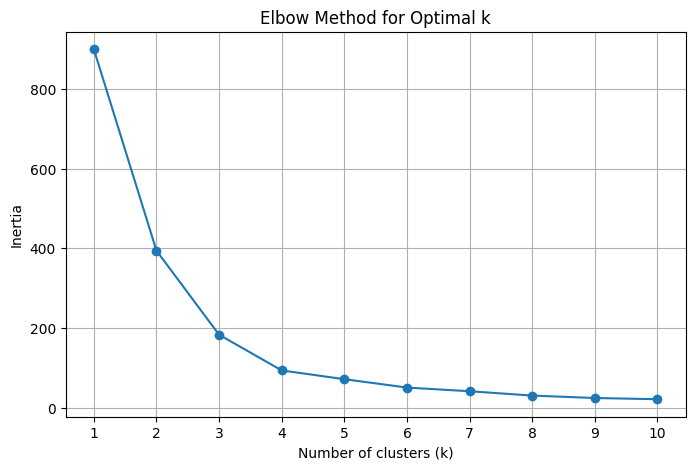

In [13]:
max_k = 10
inertias = []

for k in range(1, max_k + 1):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(scaled_rfm)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, max_k + 1), inertias, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.xticks(range(1, max_k + 1))
plt.grid(True)
plt.show()

# Choosing k — Silhouette Score

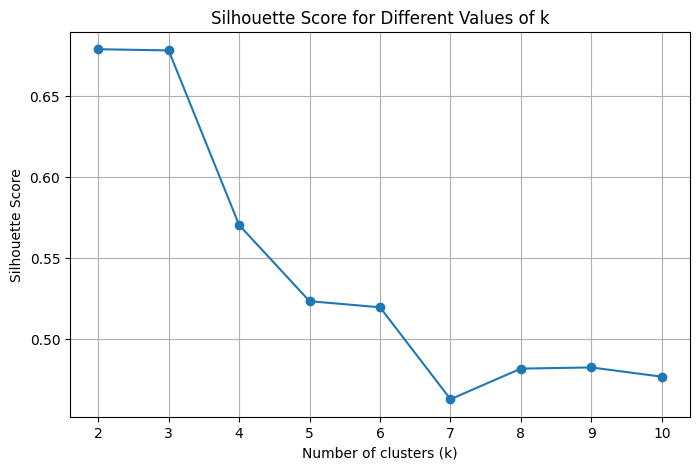

k=2: Silhouette Score=0.6789
k=3: Silhouette Score=0.6782
k=4: Silhouette Score=0.5702
k=5: Silhouette Score=0.5232
k=6: Silhouette Score=0.5194
k=7: Silhouette Score=0.4626
k=8: Silhouette Score=0.4815
k=9: Silhouette Score=0.4822
k=10: Silhouette Score=0.4765


In [14]:
min_k = 2
silhouette_scores = []

for k in range(min_k, max_k + 1):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(scaled_rfm)
    score = silhouette_score(scaled_rfm, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8, 5))
plt.plot(range(min_k, max_k + 1), silhouette_scores, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Different Values of k')
plt.xticks(range(min_k, max_k + 1))
plt.grid(True)
plt.show()

for k, score in zip(range(min_k, max_k + 1), silhouette_scores):
    print(f"k={k}: Silhouette Score={score:.4f}")

In [15]:
k_values = list(range(min_k, max_k + 1))

best_k = k_values[np.argmax(silhouette_scores)]
best_score = max(silhouette_scores)

print("Best k based on Silhouette Score:", best_k)
print(f"Best Silhouette Score: {best_score:.4f}")

Best k based on Silhouette Score: 2
Best Silhouette Score: 0.6789


In [16]:
candidate_ks = [2, 3, 4]

for k in candidate_ks:
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = km.fit_predict(scaled_rfm)

    temp_rfm = rfm.copy()
    temp_rfm['Cluster'] = labels

    profile = temp_rfm.groupby('Cluster')[
        ['Recency', 'Frequency', 'Monetary']
    ].mean()

    print(f"\n{'=' * 40}")
    print(f"Cluster Profile for k = {k}")
    print('=' * 40)

    print(profile.round(2))


Cluster Profile for k = 2
         Recency  Frequency  Monetary
Cluster                              
0           8.40       35.0  29683.61
1          61.78        8.7   2661.07

Cluster Profile for k = 3
         Recency  Frequency  Monetary
Cluster                              
0           8.40      35.00  29683.61
1          43.59       9.32   2876.90
2         258.59       2.09    326.14

Cluster Profile for k = 4
         Recency  Frequency  Monetary
Cluster                              
0          71.57       4.23    752.49
1           8.40      35.00  29683.61
2         263.38       2.10    320.48
3          20.22      13.67   4700.17


#k_means

In [17]:
# Validate the selected k

FINAL_K = 3

final_kmeans = KMeans(
    n_clusters=FINAL_K,
    random_state=RANDOM_STATE,
    n_init=10
)

final_labels = final_kmeans.fit_predict(scaled_rfm)

rfm['Cluster'] = final_labels

print("Final number of clusters:", FINAL_K)

print("\nCustomers per cluster:")
print(rfm['Cluster'].value_counts().sort_index())

print("\nFinal cluster profiles:")
print(
    rfm.groupby('Cluster')[
        ['Recency', 'Frequency', 'Monetary']
    ].mean().round(2)
)

Final number of clusters: 3

Customers per cluster:
Cluster
0     40
1    238
2     22
Name: count, dtype: int64

Final cluster profiles:
         Recency  Frequency  Monetary
Cluster                              
0           8.40      35.00  29683.61
1          43.59       9.32   2876.90
2         258.59       2.09    326.14


In [18]:
cluster_names = {
    0: "VIP / High-Value Customers",
    1: "Regular Customers",
    2: "Dormant / At-Risk Customers"
}

rfm['Persona'] = rfm['Cluster'].map(cluster_names)

rfm.head()

,customer_id,Recency,Frequency,Monetary,Cluster,Persona
0,5001,2,16,5172.45,1,Regular Customers
1,5002,23,18,6158.98,1,Regular Customers
2,5003,37,3,654.12,1,Regular Customers
3,5004,5,35,31050.88,0,VIP / High-Value Customers
4,5005,26,16,5700.91,1,Regular Customers


In [19]:
print(
    rfm.groupby(['Cluster', 'Persona'])
       .size()
       .reset_index(name='Customers')
)


   Cluster                      Persona  Customers
0        0   VIP / High-Value Customers         40
1        1            Regular Customers        238
2        2  Dormant / At-Risk Customers         22


In [20]:
rfm.to_csv(
    "RFM_clustered.csv",
    index=False
)

print("Clustered RFM table saved successfully!")

Clustered RFM table saved successfully!


## PCA + Visualization

In [21]:
# PCA + Visualization

# Apply PCA to reduce RFM features to 2 dimensions
pca = PCA(n_components=2)

pca_components = pca.fit_transform(scaled_rfm)

# Create PCA DataFrame
pca_df = pd.DataFrame(
    pca_components,
    columns=['PC1', 'PC2']
)

pca_df['Cluster'] = rfm['Cluster']

pca_df['Persona'] = rfm['Persona']

print(pca_df.head())

        PC1       PC2  Cluster                     Persona
0  0.500577 -0.653243        1           Regular Customers
1  0.550598 -0.296255        1           Regular Customers
2 -0.809335 -0.655261        1           Regular Customers
3  3.308690  0.850497        0  VIP / High-Value Customers
4  0.379754 -0.317960        1           Regular Customers


In [22]:
# Explained variance
explained_variance = pca.explained_variance_ratio_

print("Explained Variance Ratio:")
print(f"PC1: {explained_variance[0]:.2%}")
print(f"PC2: {explained_variance[1]:.2%}")
print(
    f"Total Explained Variance: "
    f"{explained_variance.sum():.2%}"
)

Explained Variance Ratio:
PC1: 75.03%
PC2: 23.72%
Total Explained Variance: 98.75%


## PCA Scatter Plot

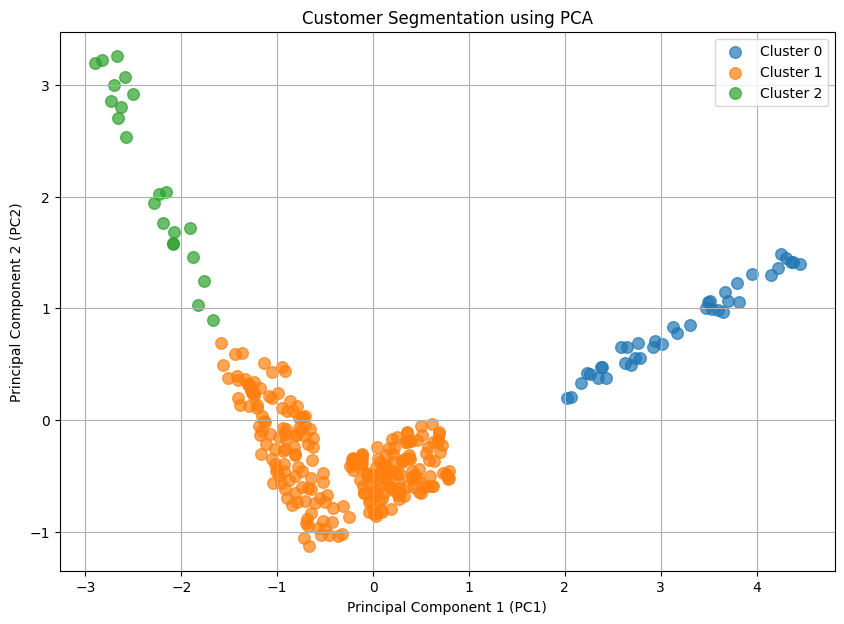

In [23]:
# PCA Visualization

plt.figure(figsize=(10,7))

for cluster in sorted(pca_df['Cluster'].unique()):

    cluster_data = pca_df[
        pca_df['Cluster'] == cluster
    ]

    plt.scatter(
        cluster_data['PC1'],
        cluster_data['PC2'],
        s=70,
        alpha=0.7,
        label=f"Cluster {cluster}"
    )

plt.xlabel("Principal Component 1 (PC1)")
plt.ylabel("Principal Component 2 (PC2)")
plt.title("Customer Segmentation using PCA")
plt.legend()
plt.grid(True)

plt.show()

#RFM Matrix + Persona Descriptions

In [24]:
# ===== RFM Matrix (3 levels: High / Medium / Low) =====
profile = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(2)

def rfm_level_3way(series, low_is_good=False):
    ranked = series.rank(ascending=low_is_good)  # 1 = best
    def label(rank):
        if rank == ranked.min():
            return "High"
        elif rank == ranked.max():
            return "Low"
        else:
            return "Medium"
    return ranked.apply(label)

rfm_matrix = pd.DataFrame({
    'Recency': profile['Recency'],
    'Recency_Level': rfm_level_3way(profile['Recency'], low_is_good=True),
    'Frequency': profile['Frequency'],
    'Frequency_Level': rfm_level_3way(profile['Frequency']),
    'Monetary': profile['Monetary'],
    'Monetary_Level': rfm_level_3way(profile['Monetary']),
})

print("RFM Matrix:")
rfm_matrix

RFM Matrix:


,Recency,Recency_Level,Frequency,Frequency_Level,Monetary,Monetary_Level
Cluster,,,,,,
0,8.40,High,35.00,High,29683.61,High
1,43.59,Medium,9.32,Medium,2876.90,Medium
2,258.59,Low,2.09,Low,326.14,Low


In [25]:
# ===== Persona Descriptions =====
persona_descriptions = {
    "VIP / High-Value Customers": (
        "These 40 customers purchase frequently (35 transactions on average), "
        "spend the most (avg. $29,683), and bought most recently (8.4 days ago). "
        "They are the core of the business's revenue. "
        "Recommended action: prioritize retention with loyalty rewards, early access "
        "to new products, and premium support — avoid generic discounts that erode "
        "margin on customers who already buy without them."
    ),
    "Regular Customers": (
        "This is the largest group (238 customers), with moderate frequency (9.3 "
        "transactions) and moderate spend ($2,877 on average), purchasing about "
        "every 6 weeks (43.6 days). They are engaged but not maximized. "
        "Recommended action: cross-sell and upsell campaigns, personalized "
        "recommendations, and engagement nudges to push them toward VIP status."
    ),
    "Dormant / At-Risk Customers": (
        "These 22 customers haven't purchased in over 8 months (258.6 days on "
        "average), buy rarely (2.1 transactions), and spend little ($326 on average). "
        "They are at high risk of full churn. "
        "Recommended action: low-cost win-back campaigns only — avoid heavy "
        "marketing spend here since the ROI of aggressive re-engagement is typically low."
    ),
}

for persona, description in persona_descriptions.items():
    print(f"\n{persona}")
    print("-" * len(persona))
    print(description)


VIP / High-Value Customers
--------------------------
These 40 customers purchase frequently (35 transactions on average), spend the most (avg. $29,683), and bought most recently (8.4 days ago). They are the core of the business's revenue. Recommended action: prioritize retention with loyalty rewards, early access to new products, and premium support — avoid generic discounts that erode margin on customers who already buy without them.

Regular Customers
-----------------
This is the largest group (238 customers), with moderate frequency (9.3 transactions) and moderate spend ($2,877 on average), purchasing about every 6 weeks (43.6 days). They are engaged but not maximized. Recommended action: cross-sell and upsell campaigns, personalized recommendations, and engagement nudges to push them toward VIP status.

Dormant / At-Risk Customers
---------------------------
These 22 customers haven't purchased in over 8 months (258.6 days on average), buy rarely (2.1 transactions), and spend li